## Carga de Archivos

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# Rutas de carpetas
path_imagenes = r"C:\Users\HP\Documents\MestriaPractico\Materia1\Repo\Semana3\test" # Carpeta con las imágenes de entrenamiento
path_segmentadas = r"C:\Users\HP\Documents\MestriaPractico\Materia1\Repo\Semana3\segmentadas"   # Donde se guardarán las imágenes segmentadas

if not os.path.exists(path_segmentadas):
    os.makedirs(path_segmentadas)

# Obtener lista de imágenes (ajusta la extensión .tif, .png o .jpg)
image_files = glob.glob(os.path.join(path_imagenes, "*.tif"))

## Comparación de Técnicas para el Área de Interés (ROI)

Técnica A: Umbralización Directa (Independiente)

Text(0.5, 1.0, 'Técnica 1: Otsu (Independiente)')

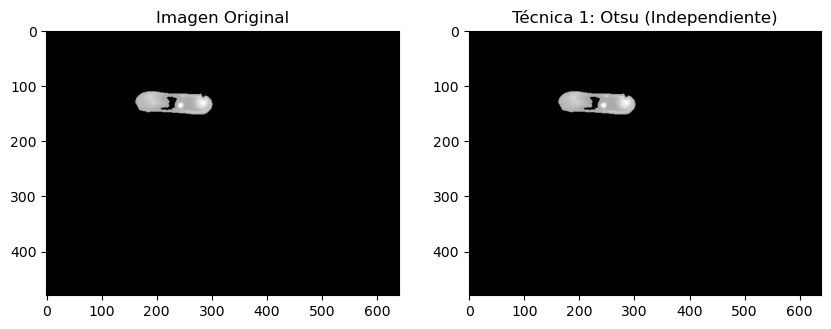

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Rutas proporcionadas
img_path = r"C:\Users\HP\Documents\MestriaPractico\Materia1\Repo\Semana3\test\1734589457070.tif"

# 1. Cargar imagen y normalizar (vital para imágenes IR de alto rango dinámico)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')

# TÉCNICA 1: INDEPENDIENTE (OTSU)
ret, mask_otsu = cv2.threshold(img_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
roi_otsu = cv2.bitwise_and(img, img, mask=mask_otsu)

# VISUALIZACIÓN DE RESULTADOS
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img, cmap='gray'); ax[0].set_title("Imagen Original")
ax[1].imshow(roi_otsu, cmap='gray'); ax[1].set_title("Técnica 1: Otsu (Independiente)")

Técnica B: Procesamiento (Secuencial)

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

def segmentar_ir_adaptativo(path_imagen):
    # 1. Cargar imagen (usamos -1 para mantener la profundidad de bits original si es 16-bit)
    img = cv2.imread(path_imagen, cv2.IMREAD_GRAYSCALE)
    if img is None: return None, None, None
    
    # Normalización para asegurar que usemos el rango 0-255 (útil para visualización y Canny)
    img_norm = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')

    # TÉCNICA 1: INDEPENDIENTE (Otsu Thresholding)
    # Otsu calcula automáticamente el mejor umbral para separar fondo de objeto
    ret, mask_otsu = cv2.threshold(img_norm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    res_otsu = cv2.bitwise_and(img, img, mask=mask_otsu)

    # TÉCNICA 2: SECUENCIAL (Filtro + Canny Adaptativo + Morfología)
    # A. Filtro para reducir ruido
    blurred = cv2.GaussianBlur(img_norm, (5, 5), 0)
    
    # B. Canny Adaptativo basado en la mediana
    v = np.median(blurred)
    sigma = 0.10
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    edges = cv2.Canny(blurred, lower, upper)
    
    # C. Morfología para cerrar el área
    kernel = np.ones((5,5), np.uint8)
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)
    dilated = cv2.dilate(closed, kernel, iterations=2)
    
    # D. Rellenar huecos (Floodfill o Contornos)
    mask_seq = np.zeros_like(img_norm)
    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        c = max(contours, key=cv2.contourArea)
        cv2.drawContours(mask_seq, [c], -1, 255, -1)
    
    res_seq = cv2.bitwise_and(img, img, mask=mask_seq)
    
    return img, res_otsu, blurred, edges, dilated, res_seq, mask_seq

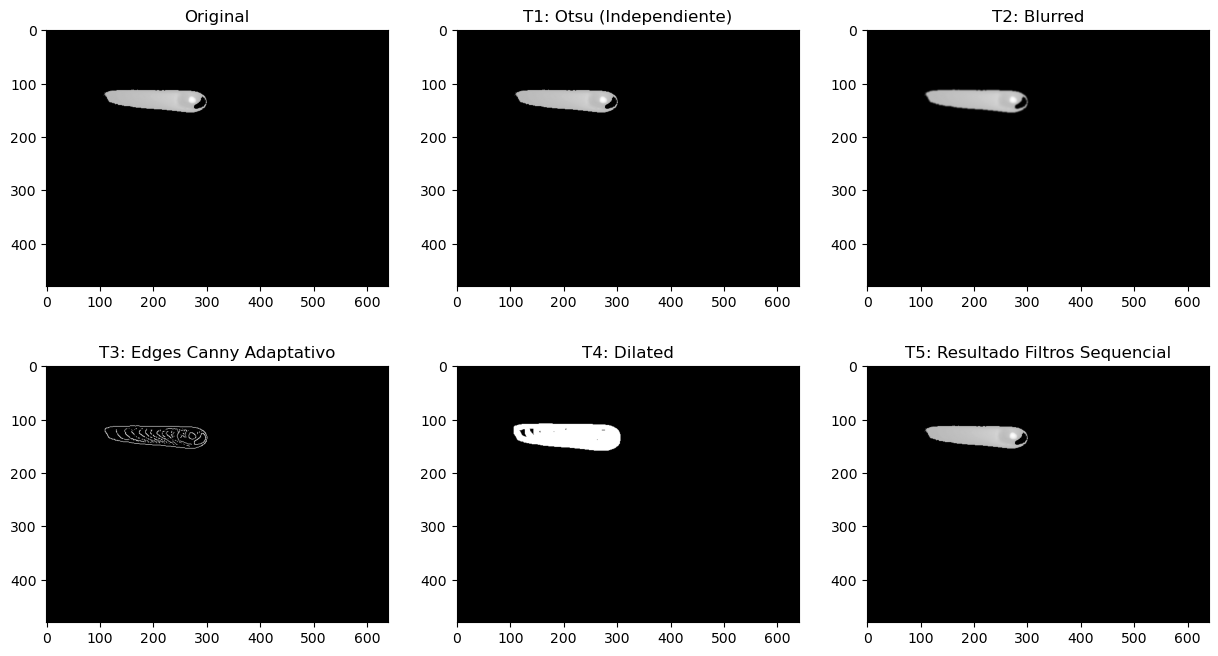

In [36]:
# PRUEBA DE DIAGNÓSTICO CON IMAGEN 1
ruta_ejemplo = r"C:\Users\HP\Documents\MestriaPractico\Materia1\Repo\Semana3\test\1734589461845.tif"

orig, t1, t2, t3 ,t4, t5,t6= segmentar_ir_adaptativo(ruta_ejemplo)

if orig is not None:
    plt.figure(figsize=(15, 8))
    plt.subplot(231), plt.imshow(orig, cmap='gray'), plt.title("Original")
    plt.subplot(232), plt.imshow(t1, cmap='gray'), plt.title("T1: Otsu (Independiente)")
    plt.subplot(233), plt.imshow(t2, cmap='gray'), plt.title("T2: Blurred")
    plt.subplot(234), plt.imshow(t3, cmap='gray'), plt.title("T3: Edges Canny Adaptativo")
    plt.subplot(235), plt.imshow(t4, cmap='gray'), plt.title("T4: Dilated")
    plt.subplot(236), plt.imshow(t5, cmap='gray'), plt.title("T5: Resultado Filtros Sequencial")
    
    plt.show()

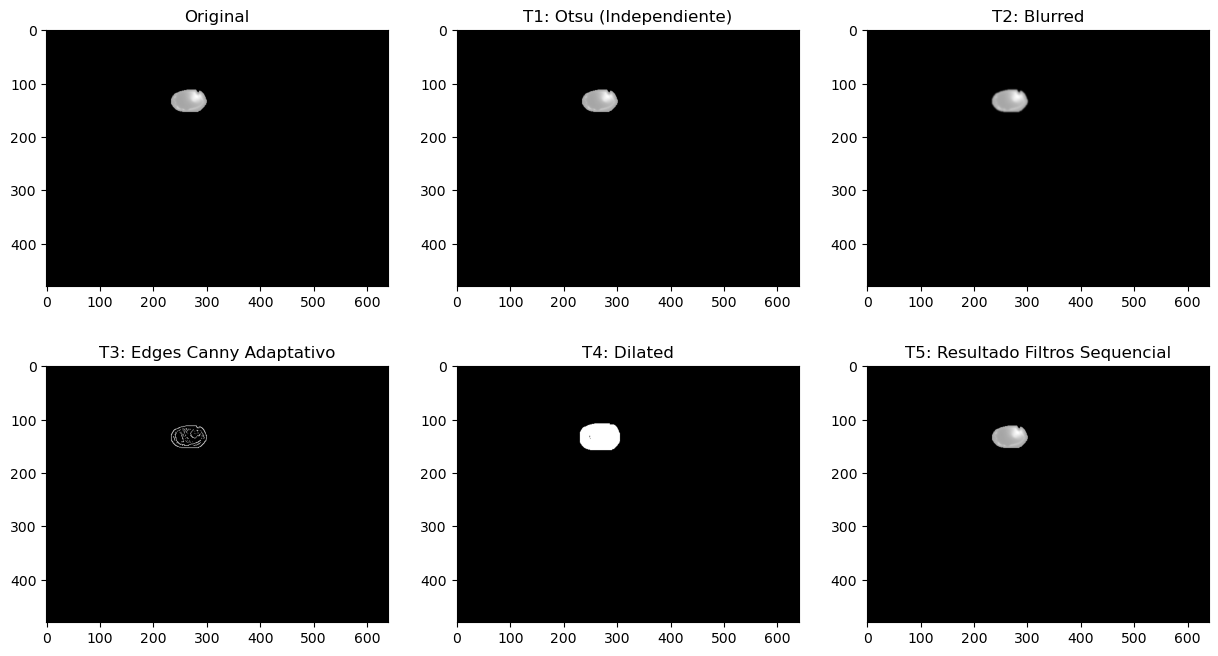

In [37]:
# PRUEBA DE DIAGNÓSTICO CON UNA IMAGEN 2
ruta_ejemplo = r"C:\Users\HP\Documents\MestriaPractico\Materia1\Repo\Semana3\test\1734589455785.tif"

orig, t1, t2, t3 ,t4, t5,t6= segmentar_ir_adaptativo(ruta_ejemplo)

if orig is not None:
    plt.figure(figsize=(15, 8))
    plt.subplot(231), plt.imshow(orig, cmap='gray'), plt.title("Original")
    plt.subplot(232), plt.imshow(t1, cmap='gray'), plt.title("T1: Otsu (Independiente)")
    plt.subplot(233), plt.imshow(t2, cmap='gray'), plt.title("T2: Blurred")
    plt.subplot(234), plt.imshow(t3, cmap='gray'), plt.title("T3: Edges Canny Adaptativo")
    plt.subplot(235), plt.imshow(t4, cmap='gray'), plt.title("T4: Dilated")
    plt.subplot(236), plt.imshow(t5, cmap='gray'), plt.title("T5: Resultado Filtros Sequencial")
    
    plt.show()

## Segmentación de todas las imagenes (Preparación para Cluster)

In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# Rutas de carpetas
path_imagenes = r"C:\Users\HP\Documents\MestriaPractico\Materia1\Repo\Semana3\test" # Carpeta con las 700 imágenes
path_segmentadas = r"C:\Users\HP\Documents\MestriaPractico\Materia1\Repo\Semana3\segmentadas"   # Donde se guardarán las imágenes segmentadas
os.makedirs(path_segmentadas, exist_ok=True)

for file_path in glob.glob(os.path.join(path_imagenes, "*.tif")):
    name = os.path.basename(file_path)
    orig, t1, t2, t3 ,t4, t5,t6= segmentar_ir_adaptativo(file_path)
    
    if t1 is not None:
        # Guardamos el resultado de la técnica Otsu para el clustering
        cv2.imwrite(os.path.join(path_segmentadas, name), t1)

Imágenes encontradas: 277


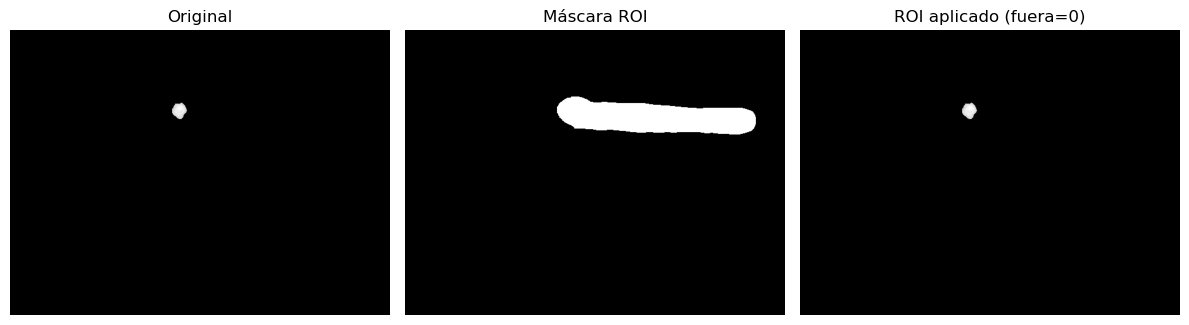

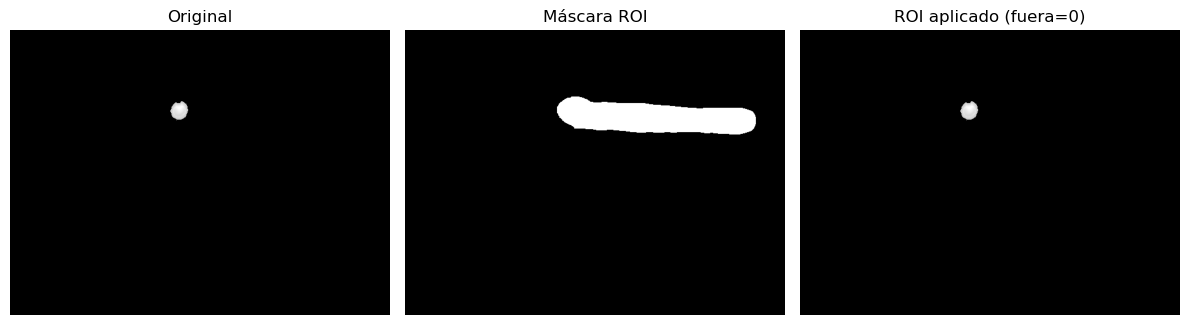

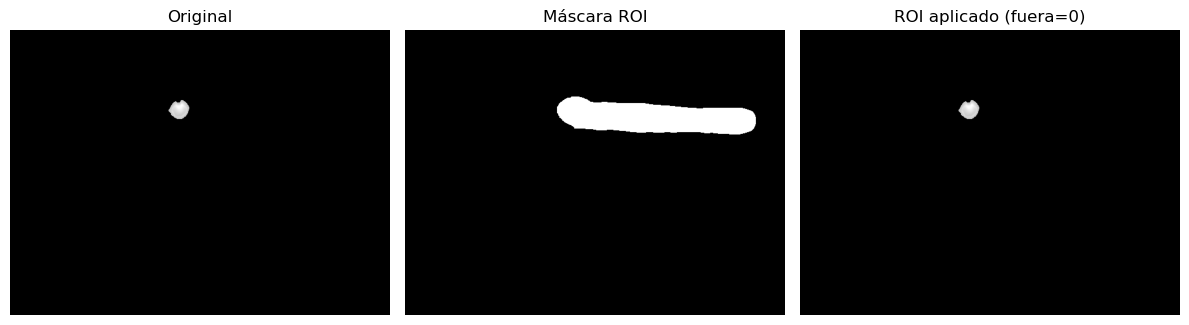

Proceso terminado correctamente.


In [44]:
BASE_IMAGE = r"C:\Users\HP\Documents\MestriaPractico\Materia1\Repo\Semana3\test\1734589528814.tif"

# 2) Ejecuta tu función y recupera mask_seq
img, res_otsu, blurred, edges, dilated, res_seq, mask_seq = segmentar_ir_adaptativo(BASE_IMAGE)

# 3) Define BEST_MASK (ROI elegida)
BEST_MASK = ((mask_seq > 0).astype(np.uint8)) * 255

TESTSET_FOLDER = r"C:\Users\HP\Documents\MestriaPractico\Materia1\Repo\Semana3\test"
OUT_FOLDER     = r"C:\Users\HP\Documents\MestriaPractico\Materia1\Repo\Semana3\test_masked2"

paths = sorted(glob.glob(os.path.join(TESTSET_FOLDER, "*.tif")))

print("Imágenes encontradas:", len(paths))

for i, p in enumerate(paths):
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)

    # Ajustar tamaño si es necesario
    if img.shape != BEST_MASK.shape:
        mask_use = cv2.resize(BEST_MASK, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
    else:
        mask_use = BEST_MASK

    # Aplicar máscara (fuera ROI = 0)
    result = cv2.bitwise_and(img, img, mask=mask_use)

    cv2.imwrite(os.path.join(OUT_FOLDER, os.path.basename(p)), result)

    # Mostrar solo primeras 3
    if i < 3:
        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1); plt.imshow(img, cmap='gray'); plt.title("Original"); plt.axis("off")
        plt.subplot(1,3,2); plt.imshow(mask_use, cmap='gray'); plt.title("Máscara ROI"); plt.axis("off")
        plt.subplot(1,3,3); plt.imshow(result, cmap='gray'); plt.title("ROI aplicado (fuera=0)"); plt.axis("off")
        plt.tight_layout()
        plt.show()

print("Proceso terminado correctamente.")